# 03 — Exploration & Visualization: Papal Corpus (Report-Aligned)

**Clay Harris (jbm2rt@virginia.edu) / DS 5001 / 2026-05-08**

This notebook is aligned to the final report and guide requirements. It focuses on modern-era analysis while documenting full-corpus context and includes the required advanced visualization types.

| Step | Description |
|------|-------------|
| 0 | Corpus overview and scope definition (full corpus + modern subset) |
| RQ1 | Modern papal signatures: topic and stylistic differentiation by pope |
| RQ2 | Modern document-type differentiation: encyclicals vs. speeches and related types |
| RQ3 | Modern temporal drift: topic and sentiment changes over time |
| 4 | Semantic analysis: Word2Vec neighborhoods and embedding geometry |
| 5 | Report-ready summary tables generated from notebook state |

In [1]:
%%time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, cosine
from sklearn.manifold import TSNE
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 8)

PROCESSED = Path('..') / 'data' / 'processed'
print("Imports and configuration complete.")

Imports and configuration complete.
CPU times: total: 3.91 s
Wall time: 8.82 s


In [9]:
%%time

# Load all processed tables (.csv, .csv.gz, or .csv.zip)
def read_processed_csv(stem, index_col=None):
    candidates = [
        PROCESSED / f'{stem}.csv',
        PROCESSED / f'{stem}.csv.gz',
        PROCESSED / f'{stem}.csv.zip',
    ]
    for path in candidates:
        if path.exists():
            return pd.read_csv(path, index_col=index_col)
    tried = ', '.join(str(p.name) for p in candidates)
    raise FileNotFoundError(f"Could not find '{stem}' in {PROCESSED}. Tried: {tried}")

TABLE_SPECS = {
    'LIBRARY': ('LIBRARY', 'doc_id'),
    'VOCAB': ('VOCAB', 'term_str'),
    'TOKEN': ('TOKEN', 'token_id'),
    'TFIDF_DTM': ('TFIDF_DTM', 'doc_id'),
    'DOC_PCA': ('DOC_PCA', 'doc_id'),
    'DOC_TOPICS': ('DOC_TOPICS', 'doc_id'),
    'LOADINGS': ('LOADINGS', 'term_str'),
    'TOPIC_TERMS': ('TOPIC_TERMS', 'term_str'),
    'EMBEDDINGS': ('EMBEDDINGS', 'term_str'),
}

for var_name, (stem, index_col) in TABLE_SPECS.items():
    # Always refresh LIBRARY from disk to avoid repeated-join inflation from downstream cells.
    if var_name == 'LIBRARY':
        globals()[var_name] = read_processed_csv(stem, index_col=index_col)
        print(f"Reloaded {var_name} from disk ({len(globals()[var_name]):,} rows)")
        continue

    existing = globals().get(var_name, None)
    if isinstance(existing, pd.DataFrame) and not existing.empty:
        print(f"Using cached {var_name} ({len(existing):,} rows)")
    else:
        globals()[var_name] = read_processed_csv(stem, index_col=index_col)
        print(f"Loaded {var_name} from disk ({len(globals()[var_name]):,} rows)")

# Topic columns can be named Topic0.. or topic_0.. depending on pipeline version.
topic_cols = [
    c for c in DOC_TOPICS.columns
    if c.lower().startswith('topic')
]

print(f"Documents: {len(LIBRARY):,}")
print(f"Tokens: {len(TOKEN):,}")
print(f"Vocabulary: {len(VOCAB):,}")
print(f"PCA Components: {len([c for c in DOC_PCA.columns if c.startswith('PC')])}")
print(f"LDA Topics: {len(topic_cols)}")

Reloaded LIBRARY from disk (17,352 rows)
Using cached VOCAB (219,533 rows)
Using cached TOKEN (28,425,031 rows)
Using cached TFIDF_DTM (551 rows)
Using cached DOC_PCA (17,352 rows)
Using cached DOC_TOPICS (17,352 rows)
Using cached LOADINGS (67,845 rows)
Using cached TOPIC_TERMS (15,000 rows)
Using cached EMBEDDINGS (31,692 rows)
Documents: 17,352
Tokens: 28,425,031
Vocabulary: 219,533
PCA Components: 10
LDA Topics: 10
CPU times: total: 93.8 ms
Wall time: 96 ms


In [10]:
%%time

import json
import re

METADATA_PATH = Path('..') / 'data' / 'encyclicals_index.json'
metadata_raw = json.loads(METADATA_PATH.read_text(encoding='utf-8'))
METADATA = pd.DataFrame(metadata_raw).set_index('doc_id')
METADATA = METADATA[~METADATA.index.duplicated(keep='first')]
metadata_cols = ['source', 'document_type', 'category', 'language', 'url', 'year']

# Make this cell idempotent by removing any prior metadata columns before joining again.
drop_cols = [c for c in ['source', 'document_type', 'category', 'language', 'url', 'year_meta'] if c in LIBRARY.columns]
if drop_cols:
    LIBRARY = LIBRARY.drop(columns=drop_cols, errors='ignore')
LIBRARY = LIBRARY.join(METADATA[metadata_cols].rename(columns={'year': 'year_meta'}), how='left')

LIBRARY['year_num'] = pd.to_numeric(LIBRARY['year_meta'], errors='coerce')
LIBRARY['year_num'] = LIBRARY['year_num'].fillna(pd.to_numeric(LIBRARY['year'], errors='coerce'))

ROMAN_NUMERAL_TOKENS = {
    'i', 'ii', 'iii', 'iv', 'v', 'vi', 'vii', 'viii', 'ix', 'x',
    'xi', 'xii', 'xiii', 'xiv', 'xv', 'xvi', 'xvii', 'xviii', 'xix', 'xx',
    'xxi', 'xxii', 'xxiii', 'xxiv',
}

POPE_DISPLAY_ALIASES = {
    'Leo Xiii': 'Pope Leo XIII',
    'Pius Xii': 'Pope Pius XII',
    'John Xxiii': 'Pope St. John XXIII',
    'Paul Vi': 'Pope Paul VI',
    'John Paul I': 'Pope John Paul I',
    'John Paul Ii': 'Pope St. John Paul II',
    'Benedict Xvi': 'Pope Benedict XVI',
    'Francesco': 'Pope Francis',
    'Leo Xiv': 'Pope Leo XIV',
}

def infer_year_from_doc_id(doc_id):
    if not isinstance(doc_id, str):
        return np.nan
    for token in re.findall(r'(?<!\d)(\d{8})(?!\d)', doc_id):
        ymd_year = int(token[:4])
        ymd_month = int(token[4:6])
        ymd_day = int(token[6:8])
        dmy_day = int(token[:2])
        dmy_month = int(token[2:4])
        dmy_year = int(token[4:8])

        ymd_valid = (1300 <= ymd_year <= 2100) and (1 <= ymd_month <= 12) and (1 <= ymd_day <= 31)
        dmy_valid = (1300 <= dmy_year <= 2100) and (1 <= dmy_month <= 12) and (1 <= dmy_day <= 31)

        if ymd_valid and not dmy_valid:
            return ymd_year
        if dmy_valid and not ymd_valid:
            return dmy_year
        if ymd_valid and dmy_valid:
            return ymd_year if 1800 <= ymd_year <= 2100 else dmy_year
    return np.nan

def format_pope_name(name):
    if not isinstance(name, str):
        return name
    if name in POPE_DISPLAY_ALIASES:
        return POPE_DISPLAY_ALIASES[name]

    parts = []
    for token in name.replace('_', ' ').split():
        if token.lower() in ROMAN_NUMERAL_TOKENS:
            parts.append(token.upper())
        else:
            parts.append(token)
    return ' '.join(parts)

missing_before = int(LIBRARY['year_num'].isna().sum())
missing_mask = LIBRARY['year_num'].isna()
LIBRARY.loc[missing_mask, 'year_num'] = pd.Index(LIBRARY.index[missing_mask]).map(infer_year_from_doc_id)
missing_after = int(LIBRARY['year_num'].isna().sum())
filled = missing_before - missing_after

def assign_era(year):
    if pd.isna(year):
        return 'Unknown'
    if year < 1891:
        return 'Pre-Modern (<=1890)'
    if year < 1962:
        return 'Social Teaching (1891-1961)'
    if year <= 1965:
        return 'Vatican II (1962-1965)'
    if year <= 2000:
        return 'Post-Vatican II (1966-2000)'
    return 'Contemporary (2001+)'

LIBRARY['era'] = LIBRARY['year_num'].apply(assign_era)
LIBRARY['vatican_ii_period'] = LIBRARY['year_num'].apply(
    lambda year: 'Pre-Vatican II (< 1962)' if pd.notna(year) and year < 1962
    else 'Transition (1962-1965)' if pd.notna(year) and 1962 <= year <= 1965
    else 'Post-Vatican II (> 1965)' if pd.notna(year) and year > 1965
    else 'Unknown'
 )
LIBRARY['pope_display'] = LIBRARY['pope'].map(format_pope_name)
LIBRARY['document_type_clean'] = LIBRARY['document_type'].fillna('unknown').str.strip().str.lower()

FULL_POPE_ORDER = (
    LIBRARY.dropna(subset=['pope', 'year_num'])
    .groupby('pope')['year_num']
    .min()
    .sort_values()
 )
FULL_POPE_COUNTS = LIBRARY['pope'].value_counts()

# Modern-only analytical scope
MODERN_START_YEAR = 1966
MODERN_LIBRARY = LIBRARY[LIBRARY['year_num'].ge(MODERN_START_YEAR)].copy()
MODERN_VATICAN_LIBRARY = MODERN_LIBRARY[MODERN_LIBRARY['source'].eq('vatican.va')].copy()
MODERN_SCOPE_LIBRARY = MODERN_VATICAN_LIBRARY.copy() if len(MODERN_VATICAN_LIBRARY) > 0 else MODERN_LIBRARY.copy()
MODERN_SCOPE_LABEL = 'vatican.va modern subset' if len(MODERN_VATICAN_LIBRARY) > 0 else 'modern dated subset (all sources)'
MODERN_RQ_LIBRARY = MODERN_SCOPE_LIBRARY[MODERN_SCOPE_LIBRARY['pope'].notna()].copy()

MODERN_POPE_ORDER = MODERN_RQ_LIBRARY.groupby('pope')['year_num'].min().sort_values()
MODERN_POPE_COUNTS = MODERN_RQ_LIBRARY['pope'].value_counts()
MODERN_TOP_POPES = [
    pope for pope in MODERN_POPE_ORDER.index
    if pope in set(MODERN_POPE_COUNTS.head(6).index)
]

TOPIC_COLS = [column for column in DOC_TOPICS.columns if column.lower().startswith('topic')]

print(f"Filled missing years from doc_id: {filled:,}")
print(f"Missing years before: {missing_before:,}")
print(f"Missing years after: {missing_after:,}")
print(f"Corpus year range after backfill: {int(LIBRARY['year_num'].min())} to {int(LIBRARY['year_num'].max())}")
print(f"Total documents in LIBRARY: {len(LIBRARY):,}")
print(f"Modern documents (>= {MODERN_START_YEAR}): {len(MODERN_LIBRARY):,}")
print(f"Modern Vatican-source documents: {len(MODERN_VATICAN_LIBRARY):,}")
print(f"Modern RQ scope used: {MODERN_SCOPE_LABEL}")
print(f"Modern pope documents in RQ scope: {len(MODERN_RQ_LIBRARY):,}")
print("\n=== Modern RQ1 papacies (chronological, top 6 by count) ===")
for pope in MODERN_TOP_POPES:
    first_year = MODERN_POPE_ORDER[pope]
    print(f"{int(first_year)} | n={MODERN_POPE_COUNTS[pope]:,} | {format_pope_name(pope)}")

Filled missing years from doc_id: 0
Missing years before: 209
Missing years after: 209
Corpus year range after backfill: 1215 to 2026
Total documents in LIBRARY: 17,352
Modern documents (>= 1966): 16,284
Modern Vatican-source documents: 16,189
Modern RQ scope used: vatican.va modern subset
Modern pope documents in RQ scope: 16,189

=== Modern RQ1 papacies (chronological, top 6 by count) ===
1966 | n=740 | Pope Paul VI
1978 | n=22 | Pope John Paul I
1978 | n=6,152 | Pope St. John Paul II
2005 | n=3,069 | Pope Benedict XVI
2013 | n=5,666 | Pope Francis
2025 | n=538 | Pope Leo XIV
CPU times: total: 406 ms
Wall time: 422 ms


---



## Section 0 — Corpus Overview and Scope Decision



Baseline descriptive statistics and the explicit modern-only analytical scope used for RQ1–RQ3.

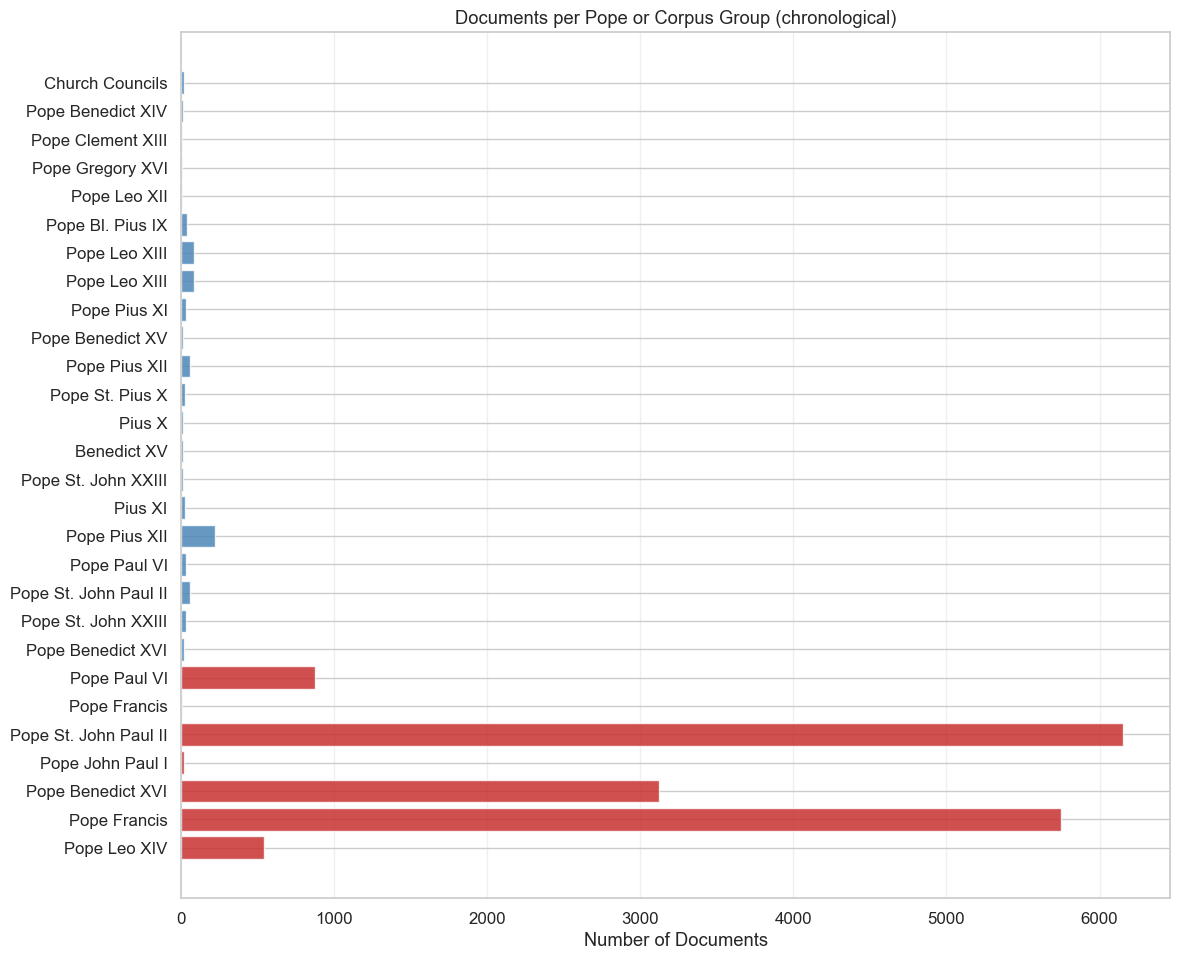

Plotted 28 popes/groups with at least 5 documents.
Earliest plotted group: Church Councils
Latest plotted group: Pope Leo XIV


In [16]:
# Documents per pope in chronological order
plot_popes = [pope for pope in FULL_POPE_ORDER.index if FULL_POPE_COUNTS.get(pope, 0) >= 5]
pope_counts = pd.Series({pope: FULL_POPE_COUNTS[pope] for pope in plot_popes})
pope_labels = [format_pope_name(pope) for pope in plot_popes]
pope_colors = ['#c62828' if pope in MODERN_TOP_POPES else 'steelblue' for pope in plot_popes]

fig, ax = plt.subplots(figsize=(12, max(8, len(plot_popes) * 0.35)))
ax.barh(range(len(plot_popes)), pope_counts.values, color=pope_colors, alpha=0.82)
ax.set_yticks(range(len(plot_popes)))
ax.set_yticklabels(pope_labels)
ax.set_xlabel('Number of Documents')
ax.set_title('Documents per Pope or Corpus Group (chronological)')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Plotted {len(plot_popes)} popes/groups with at least 5 documents.")
print(f"Earliest plotted group: {format_pope_name(plot_popes[0])}")
print(f"Latest plotted group: {format_pope_name(plot_popes[-1])}")

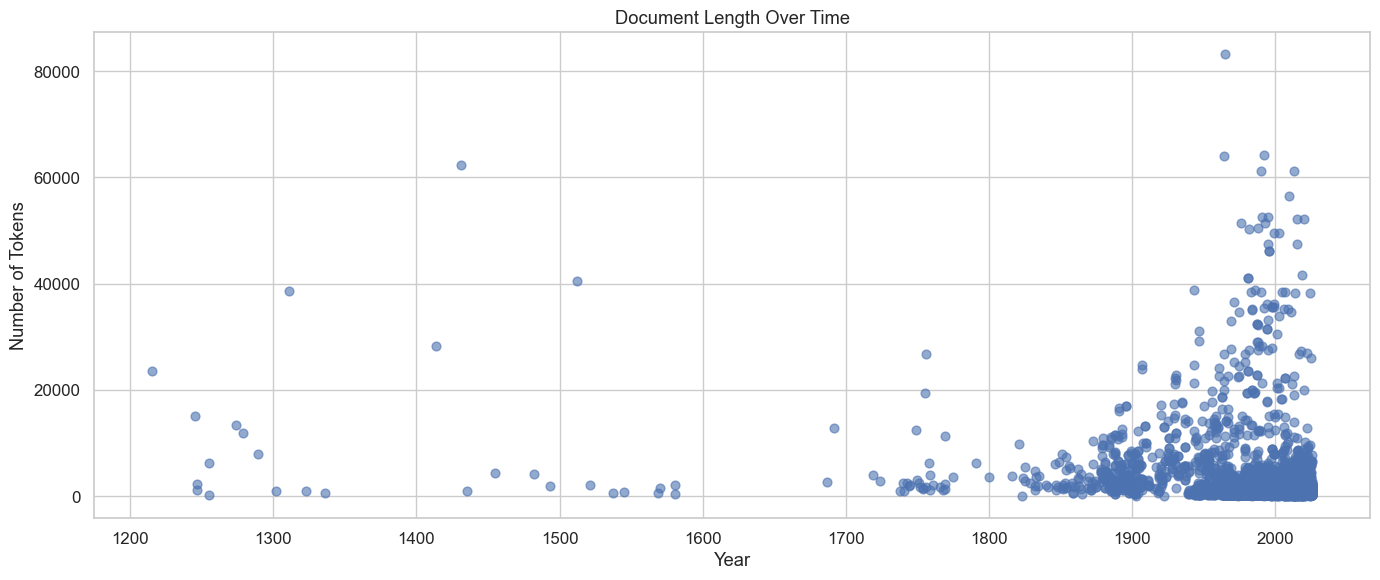

In [17]:
# Document length distribution over time (uses year_num with backfill)

fig, ax = plt.subplots(figsize=(14, 6))

ax.scatter(LIBRARY['year_num'], LIBRARY['n_tokens'], alpha=0.6, s=40)

ax.set_xlabel('Year')

ax.set_ylabel('Number of Tokens')

ax.set_title('Document Length Over Time')

plt.tight_layout()

plt.show()

---

## RQ1 — Modern Papal Signatures

**Research Question:** Within dated post-1965 documents, do papacies show distinct topic and sentiment profiles?

The notebook uses the modern Vatican subset when dated rows are available; otherwise it falls back to the modern dated subset across sources to avoid empty-group artifacts.

In [18]:
# Load explained variance for PCA interpretation
explained_variance_candidates = [
    PROCESSED / 'explained_variance.csv',
    PROCESSED / 'explained_variance.csv.gz',
    PROCESSED / 'explained_variance.csv.zip',
]

explained_var_values = None
for path in explained_variance_candidates:
    if path.exists():
        explained_var_raw = pd.read_csv(path, header=None)
        explained_var_values = pd.to_numeric(explained_var_raw.iloc[1:, 1], errors='coerce').dropna().to_numpy()
        break

if explained_var_values is None or len(explained_var_values) == 0:
    pc_cols = [c for c in DOC_PCA.columns if c.startswith('PC')]
    explained_var_values = np.repeat(np.nan, len(pc_cols))

EXPLAINED_VAR = pd.Series(
    explained_var_values,
    index=[f'PC{i}' for i in range(len(explained_var_values))]
)
EXPLAINED_VAR

PC0    0.003759
PC1    0.003667
PC2    0.003636
PC3    0.003572
PC4    0.003084
PC5    0.002821
PC6    0.002579
PC7    0.002573
PC8    0.002363
PC9    0.002248
dtype: float64

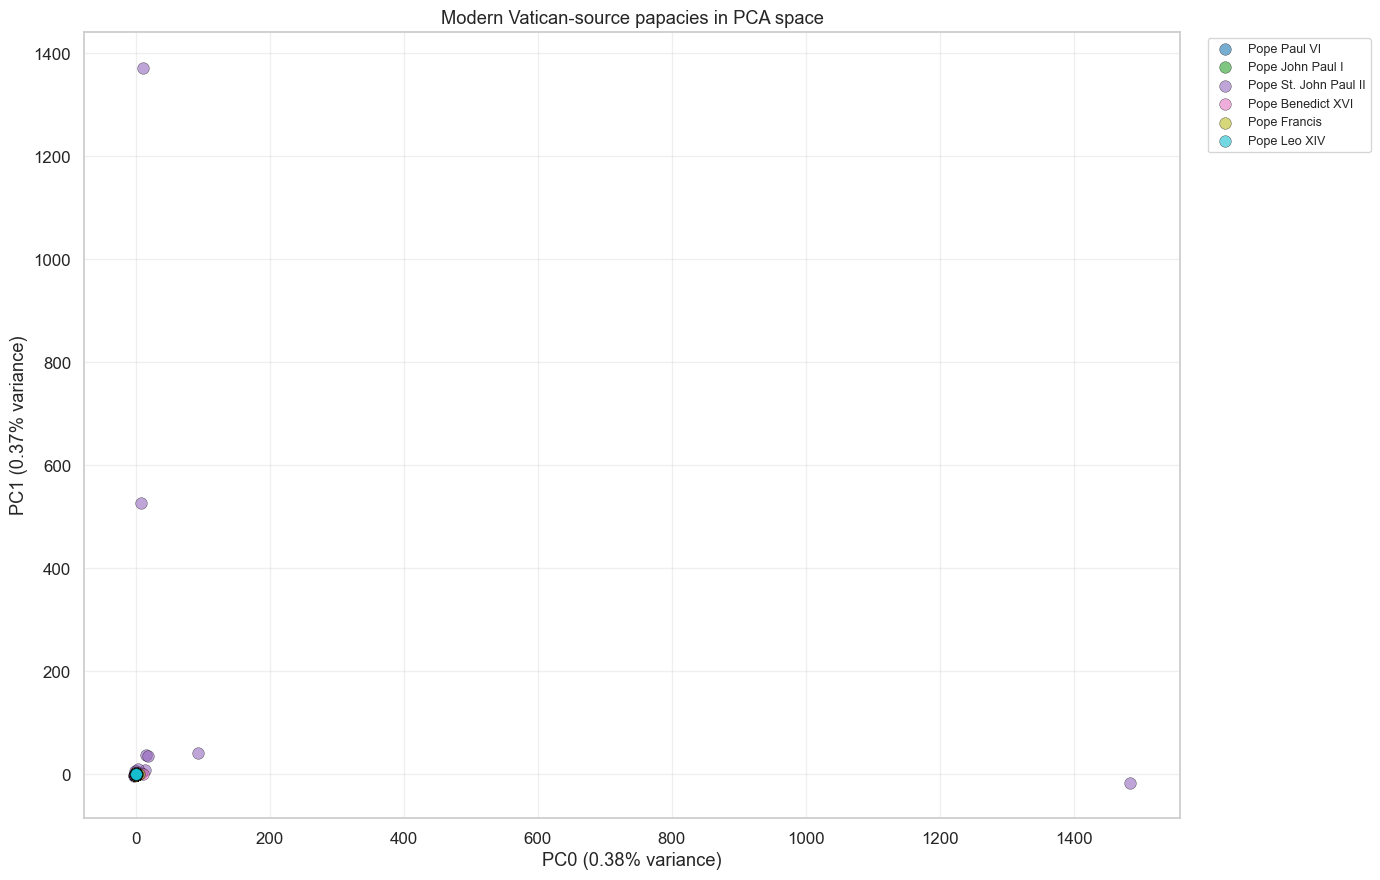

pope
Pope Paul VI              740
Pope John Paul I           22
Pope St. John Paul II    6152
Pope Benedict XVI        3069
Pope Francis             5666
Pope Leo XIV              538
Name: count, dtype: int64
CPU times: total: 562 ms
Wall time: 556 ms


In [19]:
%%time

# RQ1.1 — PCA scatter for modern Vatican-source papal documents only
pca_with_meta = DOC_PCA.join(MODERN_RQ_LIBRARY[['pope', 'pope_display', 'year_num']], how='inner')
pca_plot = pca_with_meta[pca_with_meta['pope'].isin(MODERN_TOP_POPES)].copy()

fig, ax = plt.subplots(figsize=(14, 9))
colors = plt.cm.tab10(np.linspace(0, 1, len(MODERN_TOP_POPES)))

for pope, color in zip(MODERN_TOP_POPES, colors):
    pope_mask = pca_plot['pope'] == pope
    ax.scatter(
        pca_plot.loc[pope_mask, 'PC0'],
        pca_plot.loc[pope_mask, 'PC1'],
        label=format_pope_name(pope),
        s=70,
        alpha=0.6,
        color=color,
        edgecolors='black',
        linewidth=0.35,
    )

ax.set_xlabel(f"PC0 ({EXPLAINED_VAR.get('PC0', np.nan):.2%} variance)")
ax.set_ylabel(f"PC1 ({EXPLAINED_VAR.get('PC1', np.nan):.2%} variance)")
ax.set_title('Modern Vatican-source papacies in PCA space')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rq1_counts = MODERN_RQ_LIBRARY[MODERN_RQ_LIBRARY['pope'].isin(MODERN_TOP_POPES)]['pope'].value_counts().reindex(MODERN_TOP_POPES)
print(rq1_counts.rename(index=format_pope_name))

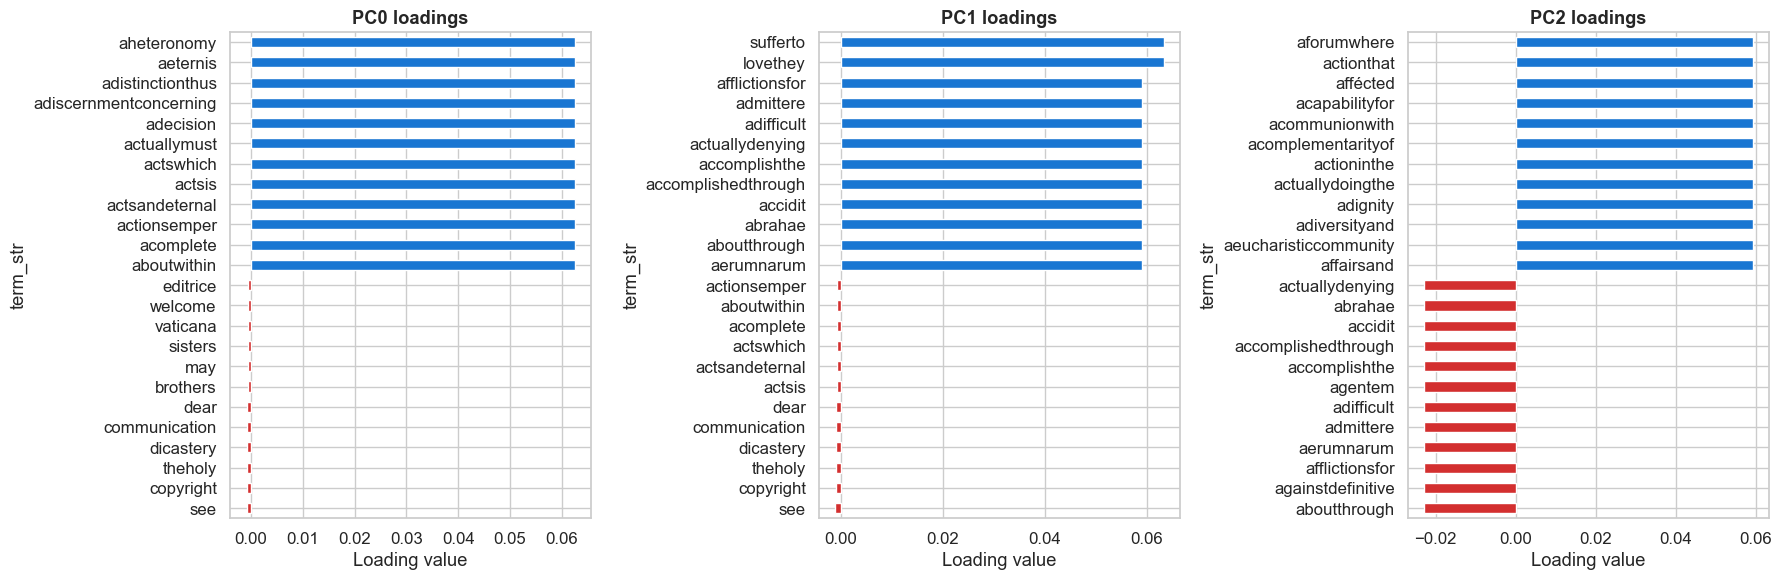


PC0
negative_terms         positive_terms
           see            aboutwithin
     copyright              acomplete
       theholy           actionsemper
     dicastery         actsandeternal
 communication                 actsis
          dear              actswhich
      brothers           actuallymust
           may              adecision
       sisters adiscernmentconcerning
      vaticana       adistinctionthus
       welcome               aeternis
      editrice            aheteronomy

PC1
negative_terms      positive_terms
           see            lovethey
     copyright            sufferto
       theholy        aboutthrough
     dicastery             abrahae
 communication             accidit
          dear accomplishedthrough
   aboutwithin       accomplishthe
     acomplete     actuallydenying
  actionsemper          adifficult
actsandeternal           admittere
        actsis          aerumnarum
     actswhich      afflictionsfor

PC2
     negative_terms        positive_

In [20]:
%%time

# RQ1.2 — PCA Loadings: Which terms drive separation?
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
loading_tables = {}

for i, ax in enumerate(axes):
    pc = f'PC{i}'
    if pc in LOADINGS.columns:
        top_pos = LOADINGS[pc].nlargest(12)
        top_neg = LOADINGS[pc].nsmallest(12)
        combined = pd.concat([top_neg, top_pos]).sort_values()
        colors = ['#d32f2f' if value < 0 else '#1976d2' for value in combined.values]
        combined.plot(kind='barh', ax=ax, color=colors)
        ax.set_title(f'{pc} loadings', fontweight='bold')
        ax.set_xlabel('Loading value')
        loading_tables[pc] = pd.DataFrame({
            'negative_terms': top_neg.index.tolist(),
            'positive_terms': top_pos.index.tolist(),
        })

plt.tight_layout()
plt.show()

for pc, table in loading_tables.items():
    print(f"\n{pc}")
    print(table.to_string(index=False))

In [21]:
%%time

# RQ1.3 — Hierarchical clustering sample for modern papal documents
# Keep a balanced sample per pope for readability and computational tractability.
sample_per_pope = 120
sampled_ids = []
for pope in MODERN_TOP_POPES:
    pope_ids = MODERN_RQ_LIBRARY[MODERN_RQ_LIBRARY['pope'] == pope].sort_values('year_num').index
    sampled_ids.extend(pope_ids[:sample_per_pope].tolist())

rq1_docs = pd.Index(sampled_ids).intersection(TFIDF_DTM.index)
tfidf_top = TFIDF_DTM.loc[rq1_docs]
dist = pdist(tfidf_top.values, metric='cosine')
Z = linkage(dist, method='ward')

labels = []
for doc_id in tfidf_top.index:
    pope = format_pope_name(MODERN_RQ_LIBRARY.loc[doc_id, 'pope'])
    title = str(MODERN_RQ_LIBRARY.loc[doc_id, 'title'])[:28]
    labels.append(f"{pope}: {title}")

fig, ax = plt.subplots(figsize=(16, max(8, len(labels) * 0.12)))
dendrogram(Z, labels=labels, orientation='right', leaf_font_size=6.5, ax=ax)
ax.set_title('Hierarchical clustering sample of modern Vatican papal documents', fontweight='bold', fontsize=12)
ax.set_xlabel('Cosine distance (TF-IDF)')
plt.tight_layout()
plt.show()

print(f"Clustered {len(tfidf_top):,} sampled documents across {len(MODERN_TOP_POPES)} modern papacies.")

ValueError: The number of observations cannot be determined on an empty distance matrix.

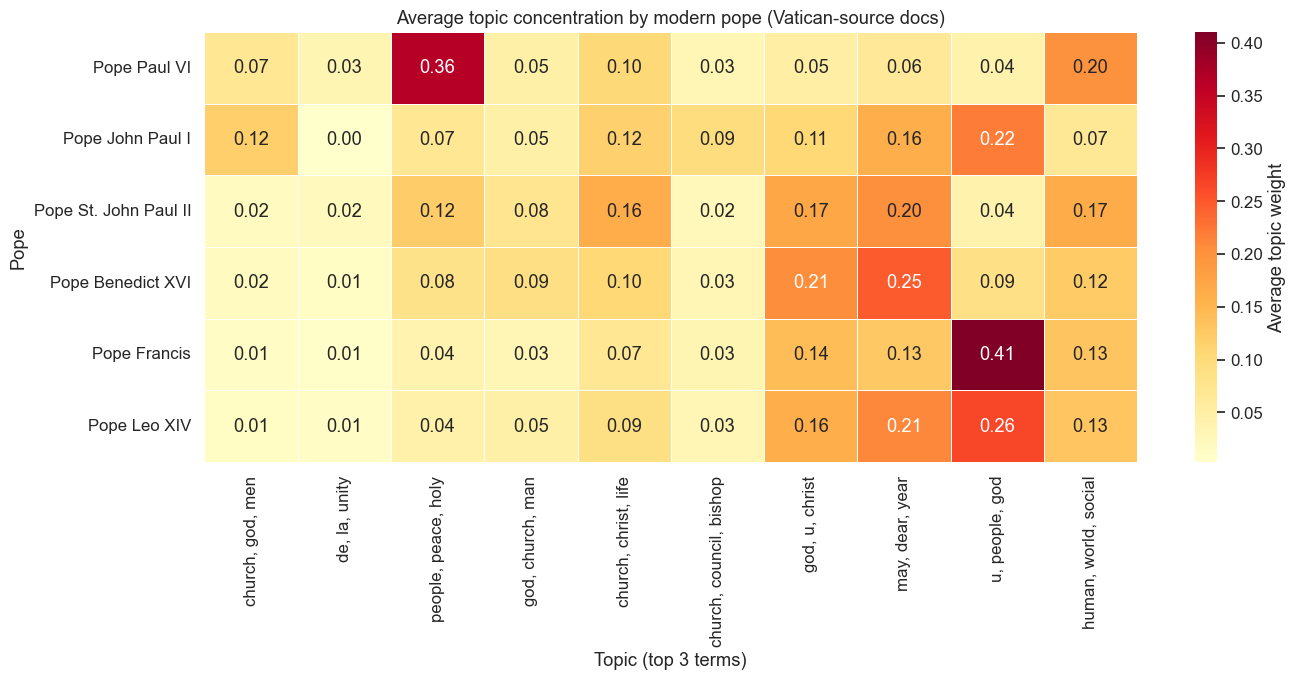

                      dominant_topic  dominant_weight
pope                                                 
Pope Paul VI                 topic_2            0.365
Pope John Paul I             topic_8            0.220
Pope St. John Paul II        topic_7            0.202
Pope Benedict XVI            topic_7            0.248
Pope Francis                 topic_8            0.410
Pope Leo XIV                 topic_8            0.265
CPU times: total: 719 ms
Wall time: 761 ms


In [22]:
%%time

# RQ1.4 — LDA topic distribution heatmap by modern pope (Vatican-source docs only)
topics_with_pope = DOC_TOPICS.join(MODERN_RQ_LIBRARY[['pope']], how='inner')
pope_topics = topics_with_pope.groupby('pope')[TOPIC_COLS].mean().loc[MODERN_TOP_POPES]

topic_labels = {}
for topic in TOPIC_COLS:
    top_words = TOPIC_TERMS[topic].nlargest(3).index.tolist()
    topic_labels[topic] = ', '.join(top_words)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pope_topics.rename(columns=topic_labels),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Average topic weight'},
    yticklabels=[format_pope_name(pope) for pope in pope_topics.index],
)
ax.set_title('Average topic concentration by modern pope (Vatican-source docs)')
ax.set_xlabel('Topic (top 3 terms)')
ax.set_ylabel('Pope')
plt.tight_layout()
plt.show()

rq1_dominant_topics = pd.DataFrame({
    'dominant_topic': pope_topics.idxmax(axis=1),
    'dominant_weight': pope_topics.max(axis=1),
}).rename(index=format_pope_name)
print(rq1_dominant_topics.round(3))

---

## RQ2 — Modern Document-Type Differentiation

**Research Question:** Within dated post-1965 documents, which document types show distinct lexical and sentiment profiles?

This RQ compares dominant modern document types to separate papal signal from genre/composition effects in the same modern scope.

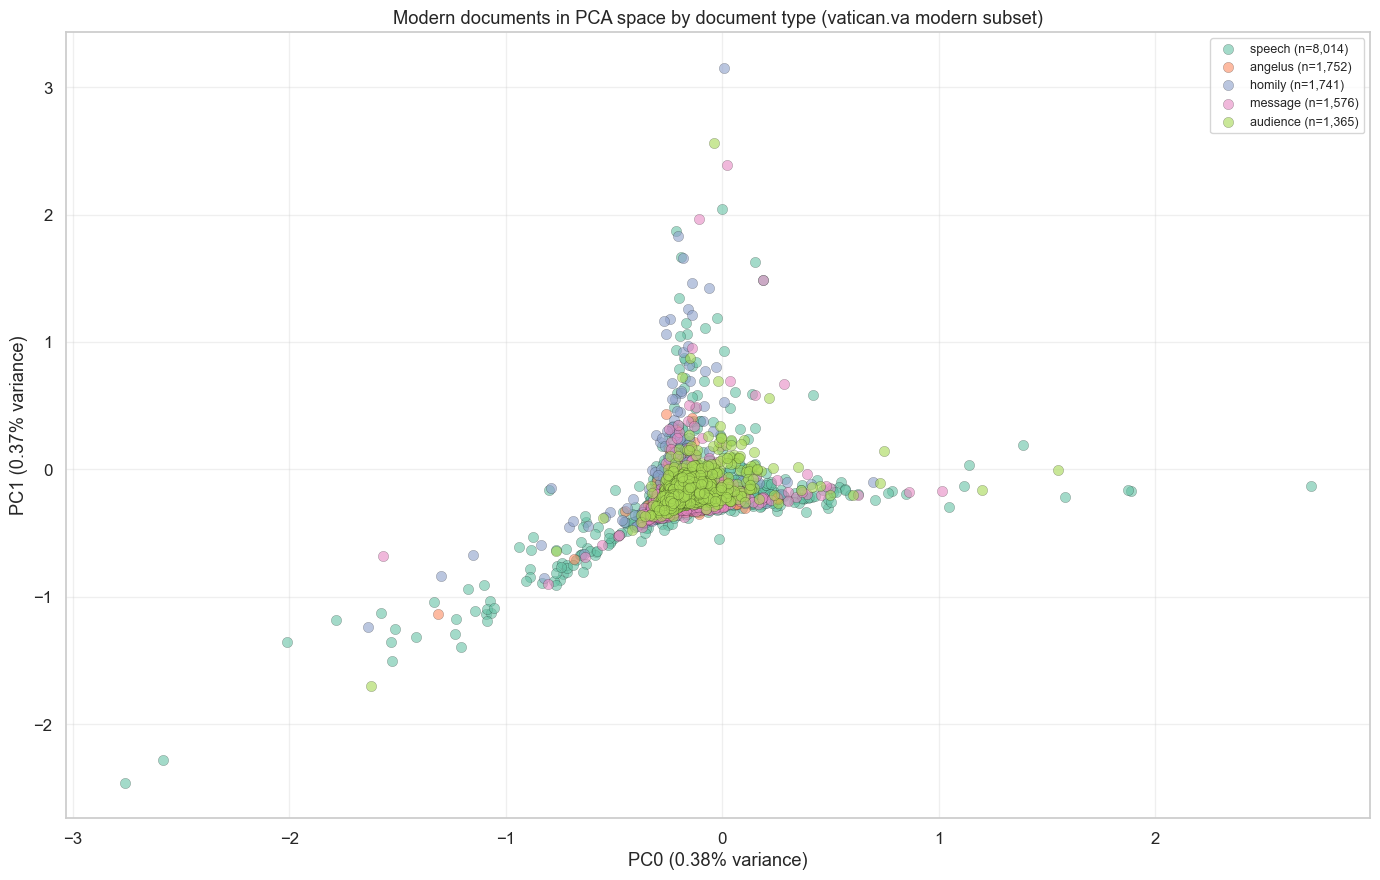

document_type_clean
speech              8014
angelus             1752
homily              1741
message             1576
audience            1365
apostolic letter     779
document             646
motu proprio          86
prayer                86
travel                59
Name: count, dtype: int64
CPU times: total: 703 ms
Wall time: 701 ms


In [23]:
%%time

# RQ2.1 — PCA scatter by modern document type
if 'EXPLAINED_VAR' not in globals():
    pc_cols = [c for c in DOC_PCA.columns if c.startswith('PC')]
    EXPLAINED_VAR = pd.Series(np.repeat(np.nan, len(pc_cols)), index=pc_cols)

doc_type_counts = MODERN_SCOPE_LIBRARY['document_type_clean'].value_counts()
TOP_DOC_TYPES = doc_type_counts[doc_type_counts >= 20].head(5).index.tolist()

pca_doc_type = DOC_PCA.join(MODERN_SCOPE_LIBRARY[['document_type_clean']], how='inner')
pca_doc_type = pca_doc_type[pca_doc_type['document_type_clean'].isin(TOP_DOC_TYPES)]

fig, ax = plt.subplots(figsize=(14, 9))
palette = sns.color_palette('Set2', n_colors=len(TOP_DOC_TYPES))

for doc_type, color in zip(TOP_DOC_TYPES, palette):
    mask = pca_doc_type['document_type_clean'] == doc_type
    ax.scatter(
        pca_doc_type.loc[mask, 'PC0'],
        pca_doc_type.loc[mask, 'PC1'],
        label=f"{doc_type} (n={mask.sum():,})",
        s=55,
        alpha=0.6,
        color=color,
        edgecolors='black',
        linewidth=0.2,
    )

ax.set_xlabel(f"PC0 ({EXPLAINED_VAR.get('PC0', np.nan):.2%} variance)")
ax.set_ylabel(f"PC1 ({EXPLAINED_VAR.get('PC1', np.nan):.2%} variance)")
ax.set_title(f"Modern documents in PCA space by document type ({MODERN_SCOPE_LABEL})")
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(doc_type_counts.head(10))

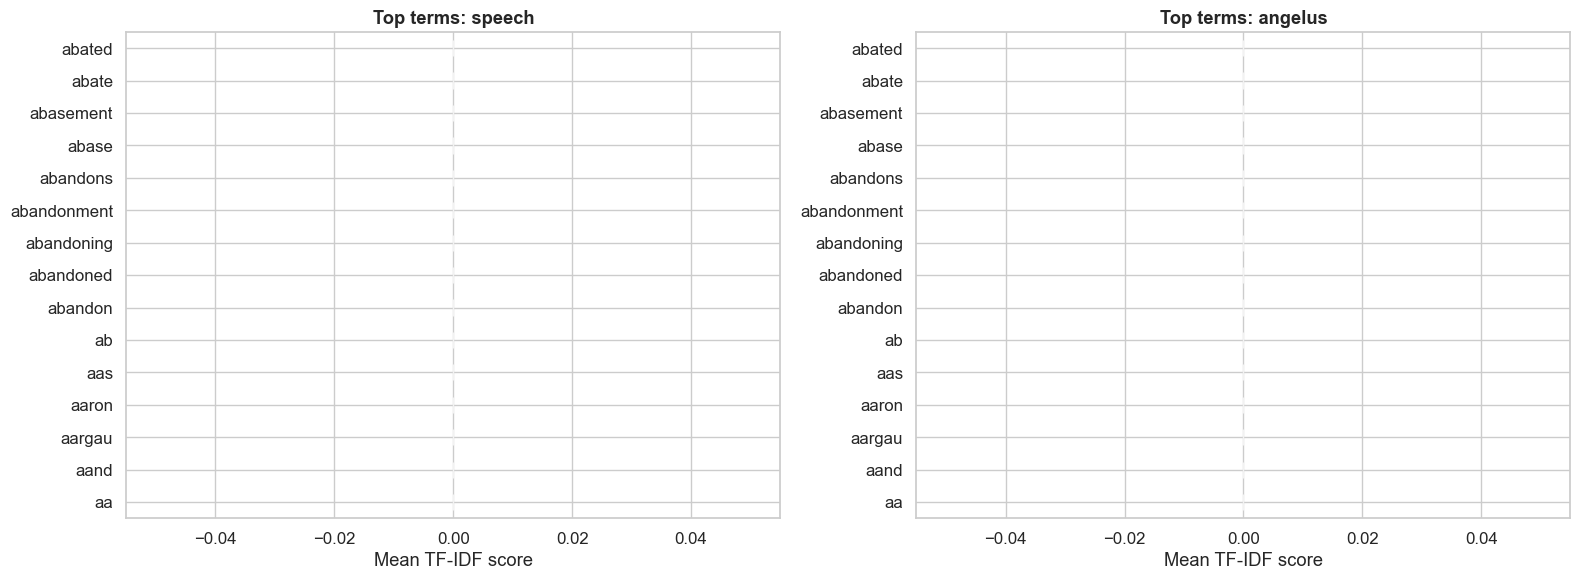

             speech  angelus
aa              0.0      0.0
aand            0.0      0.0
aargau          0.0      0.0
aaron           0.0      0.0
aas             0.0      0.0
ab              0.0      0.0
abandon         0.0      0.0
abandoned       0.0      0.0
abandoning      0.0      0.0
abandonment     0.0      0.0
abandons        0.0      0.0
abase           0.0      0.0
abasement       0.0      0.0
abate           0.0      0.0
abated          0.0      0.0
CPU times: total: 672 ms
Wall time: 685 ms


In [24]:
%%time

# RQ2.2 — Vocabulary shift by modern document type (top 2 types)
top_types = MODERN_SCOPE_LIBRARY['document_type_clean'].value_counts().head(2).index.tolist()
type_a, type_b = top_types[0], top_types[1]

type_a_docs = MODERN_SCOPE_LIBRARY[MODERN_SCOPE_LIBRARY['document_type_clean'] == type_a].index.intersection(TFIDF_DTM.index)
type_b_docs = MODERN_SCOPE_LIBRARY[MODERN_SCOPE_LIBRARY['document_type_clean'] == type_b].index.intersection(TFIDF_DTM.index)

type_a_tfidf = TFIDF_DTM.loc[type_a_docs].mean()
type_b_tfidf = TFIDF_DTM.loc[type_b_docs].mean()

type_a_top = type_a_tfidf[type_a_tfidf.index.str.isalpha()].nlargest(15)
type_b_top = type_b_tfidf[type_b_tfidf.index.str.isalpha()].nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
type_a_top.plot(kind='barh', ax=axes[0], color='#2e7d32', alpha=0.75)
axes[0].set_title(f"Top terms: {type_a}", fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF score')

type_b_top.plot(kind='barh', ax=axes[1], color='#1565c0', alpha=0.75)
axes[1].set_title(f"Top terms: {type_b}", fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF score')

plt.tight_layout()
plt.show()

type_vocab_shift = pd.DataFrame({type_a: type_a_top, type_b: type_b_top})
print(type_vocab_shift.fillna(0).round(5))

In [25]:
%%time

# RQ2.3 — Sentiment profiles by modern document type
sentiment_col = 'vader_compound'
doc_type_sent = MODERN_SCOPE_LIBRARY.dropna(subset=[sentiment_col]).copy()
top_types_sent = doc_type_sent['document_type_clean'].value_counts().head(4).index.tolist()
doc_type_sent = doc_type_sent[doc_type_sent['document_type_clean'].isin(top_types_sent)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(
    data=doc_type_sent,
    x='document_type_clean',
    y=sentiment_col,
    order=top_types_sent,
    ax=axes[0],
    palette='Set3',
)
axes[0].set_xlabel('Document type')
axes[0].set_ylabel('VADER compound score')
axes[0].set_title('Sentiment by modern document type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(True, alpha=0.3)

for doc_type in top_types_sent:
    subset = doc_type_sent.loc[doc_type_sent['document_type_clean'] == doc_type, sentiment_col]
    if len(subset) > 5:
        subset.plot.kde(ax=axes[1], label=doc_type, linewidth=2)
axes[1].set_xlabel('VADER compound score')
axes[1].set_ylabel('Density')
axes[1].set_title('Sentiment density by document type', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

doc_type_sent_summary = (
    doc_type_sent.groupby('document_type_clean')[sentiment_col]
    .agg(['count', 'mean', 'median', 'std'])
    .reindex(top_types_sent)
)
print(doc_type_sent_summary.round(3))

KeyError: ['vader_compound']

---

## RQ3 — Modern Temporal Drift (1966–2026)

**Research Question:** Within the modern period, how do topic emphasis and sentiment profiles drift over time?

This section mirrors the report logic: (1) dynamic topic trajectories, (2) raw vs pope+document-type controlled drift, and (3) decade-level sentiment trend context.

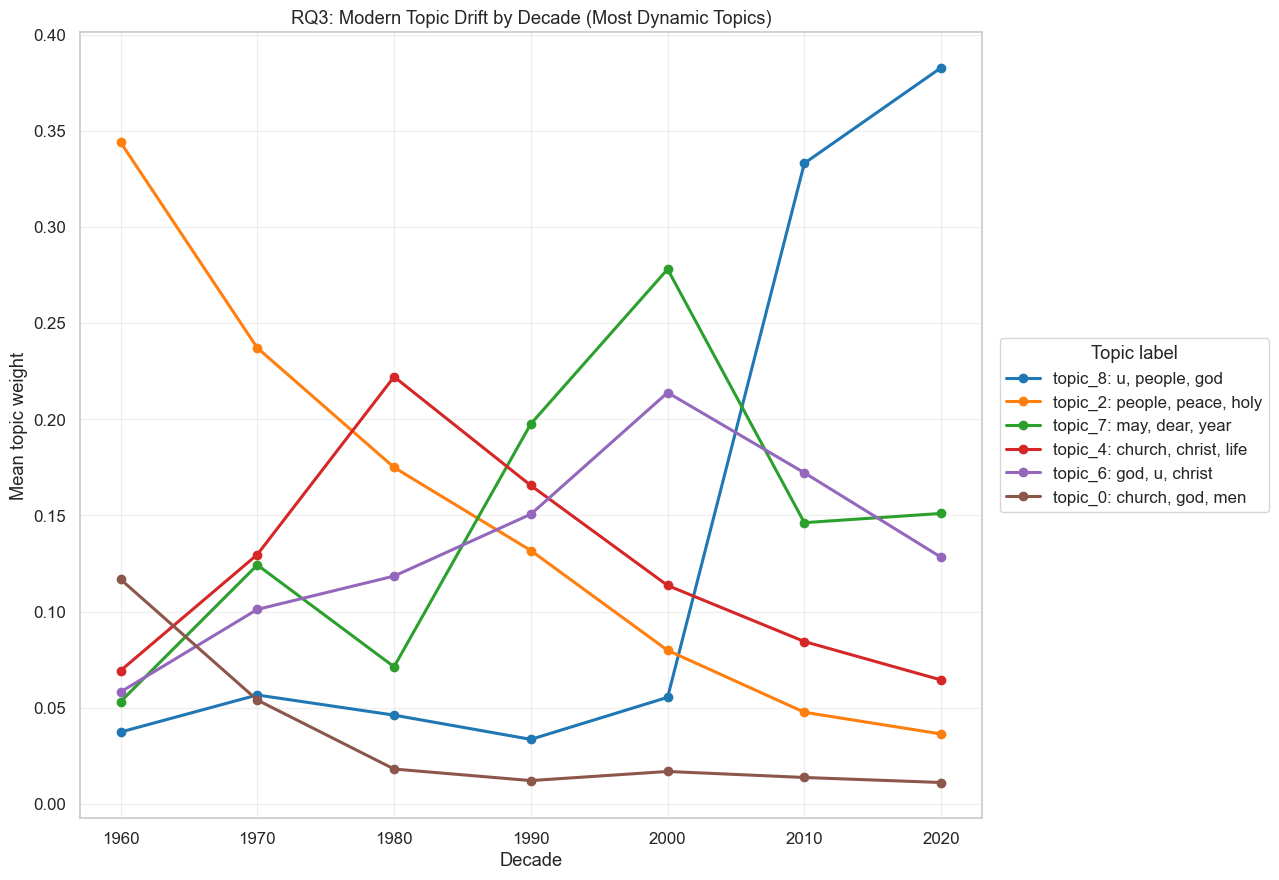

topic_8    0.349
topic_2    0.308
topic_7    0.225
topic_4    0.158
topic_6    0.156
topic_0    0.106
dtype: float64
CPU times: total: 484 ms
Wall time: 550 ms


In [26]:
%%time

# RQ3.1 — Topic evolution across modern decades (report-aligned single-panel view)
topics_time = DOC_TOPICS.join(MODERN_LIBRARY[['year_num']], how='inner').dropna(subset=['year_num']).copy()
topics_time['decade'] = (topics_time['year_num'] // 10 * 10).astype(int)
decade_topics = topics_time.groupby('decade')[TOPIC_COLS].mean()

topic_spread = (decade_topics.max(axis=0) - decade_topics.min(axis=0)).sort_values(ascending=False)
plot_topics = topic_spread.head(6).index.tolist()

fig, ax = plt.subplots(figsize=(13, 9))
palette = sns.color_palette('tab10', n_colors=len(plot_topics))
for topic, color in zip(plot_topics, palette):
    top_words = TOPIC_TERMS[topic].nlargest(3).index.tolist()
    label = f"{topic}: {', '.join(top_words)}"
    ax.plot(decade_topics.index, decade_topics[topic], marker='o', linewidth=2.2, label=label, color=color)

ax.set_title('RQ3: Modern Topic Drift by Decade (Most Dynamic Topics)')
ax.set_xlabel('Decade')
ax.set_ylabel('Mean topic weight')
ax.grid(alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True, title='Topic label')
plt.tight_layout()
plt.show()

print((decade_topics[plot_topics].max() - decade_topics[plot_topics].min()).sort_values(ascending=False).round(3))

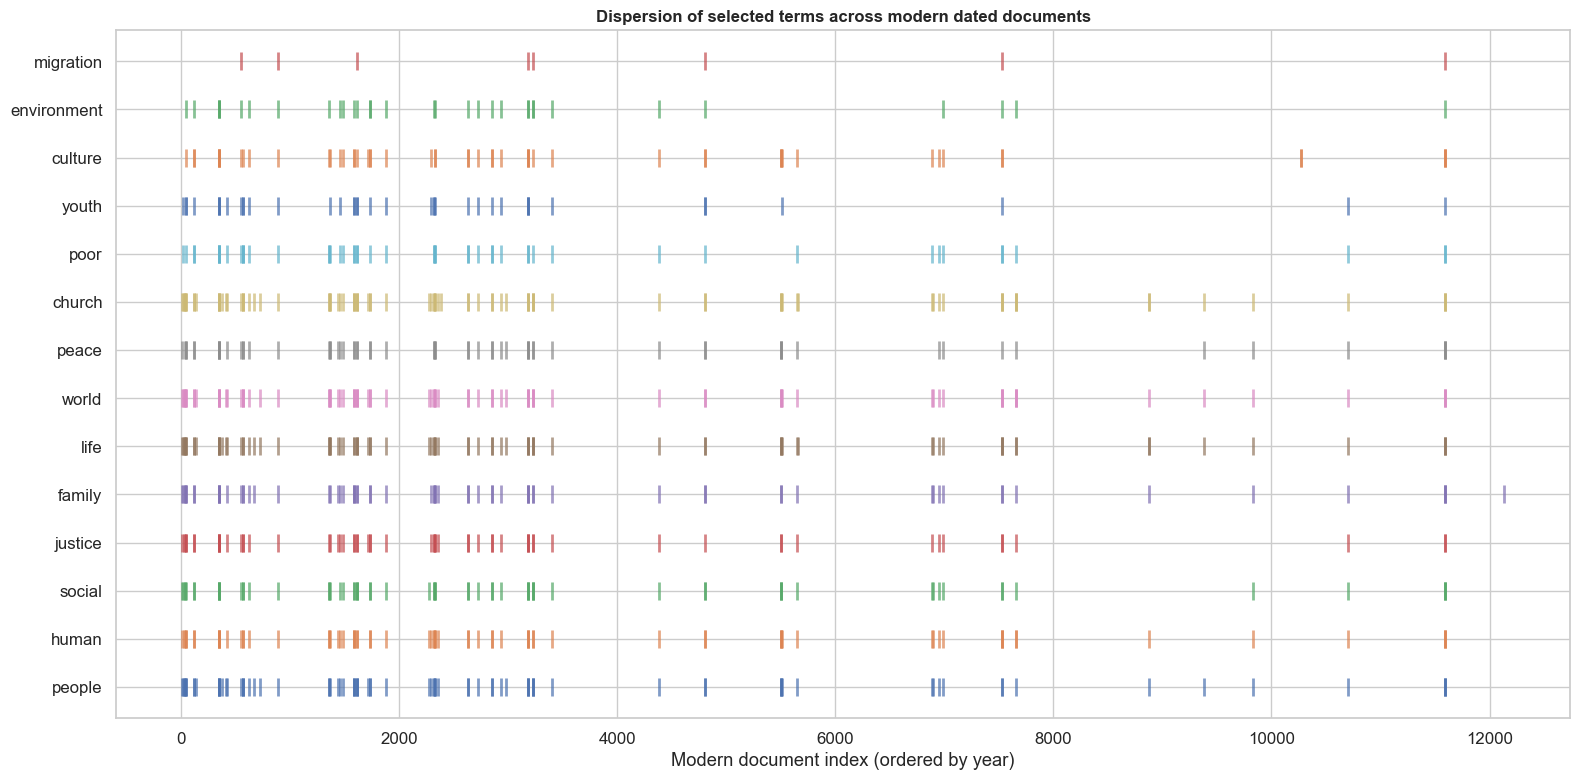

church         457
people         421
life           399
world          383
human          359
peace          324
justice        295
family         210
social         186
poor           184
youth          159
culture        129
environment     52
migration       13
dtype: int64
CPU times: total: 562 ms
Wall time: 616 ms


In [27]:
%%time



# RQ3.2 — Dispersion plot: modern social-language terms across dated modern docs

modern_terms = [

    'people', 'human', 'social', 'justice', 'family', 'life',

    'world', 'peace', 'church', 'poor', 'youth', 'culture',

    'environment', 'migration'

]



doc_order = MODERN_LIBRARY.dropna(subset=['year_num']).sort_values('year_num').index.tolist()

doc_positions = {doc_id: position for position, doc_id in enumerate(doc_order)}

available_terms = [term for term in modern_terms if term in TFIDF_DTM.columns]



fig, ax = plt.subplots(figsize=(16, 8))

for term_idx, term in enumerate(available_terms):

    docs_with_term = TFIDF_DTM.index[TFIDF_DTM[term] > 0]

    positions = [doc_positions[doc_id] for doc_id in docs_with_term if doc_id in doc_positions]

    ax.scatter(positions, [term_idx] * len(positions), marker='|', s=180, linewidths=2, alpha=0.7)



ax.set_yticks(range(len(available_terms)))

ax.set_yticklabels(available_terms)

ax.set_xlabel('Modern document index (ordered by year)')

ax.set_title('Dispersion of selected terms across modern dated documents', fontweight='bold', fontsize=12)

plt.tight_layout()

plt.show()



term_doc_counts = pd.Series({term: int((TFIDF_DTM[term] > 0).sum()) for term in available_terms}).sort_values(ascending=False)

print(term_doc_counts)

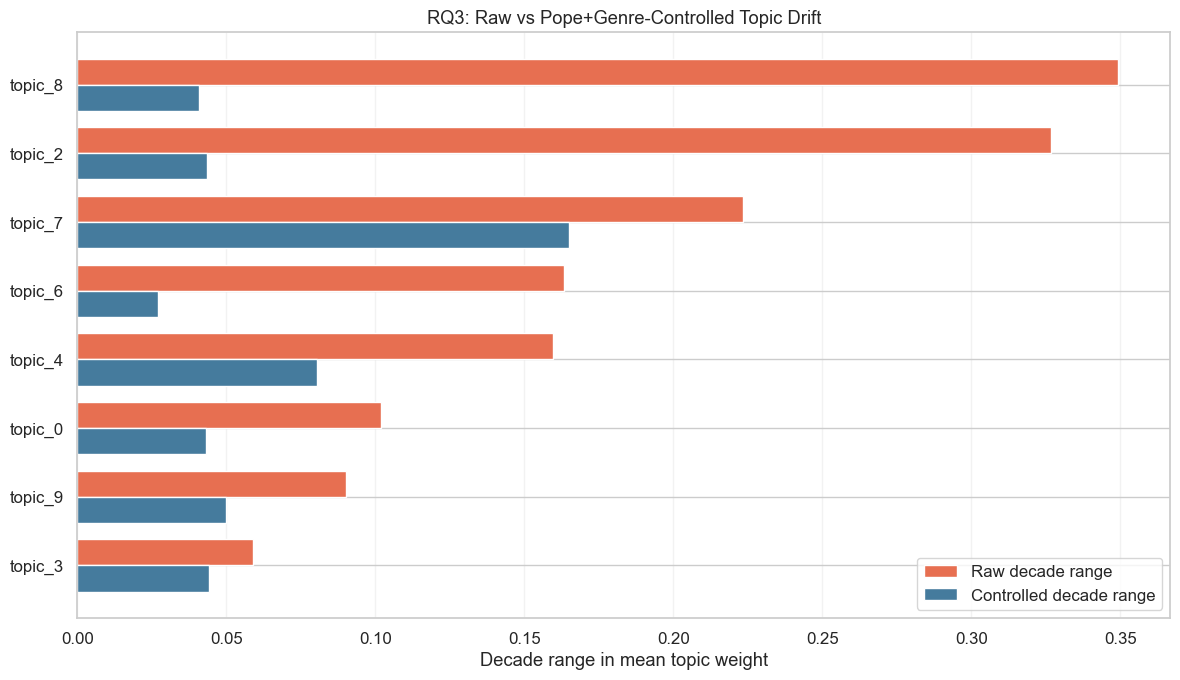

     topic  raw_range  controlled_range
7  topic_3      0.059             0.044
6  topic_9      0.090             0.050
5  topic_0      0.102             0.043
4  topic_4      0.160             0.080
3  topic_6      0.163             0.027
2  topic_7      0.224             0.165
1  topic_2      0.327             0.043
0  topic_8      0.349             0.041
CPU times: total: 484 ms
Wall time: 476 ms


In [28]:
%%time

# RQ3.3 — Raw vs pope+document-type controlled decade-range comparison
rq3_df = DOC_TOPICS.join(
    MODERN_SCOPE_LIBRARY[['year_num', 'pope', 'document_type_clean']],
    how='inner',
).dropna(subset=['year_num']).copy()
rq3_df = rq3_df[rq3_df['pope'].notna()]
rq3_df['decade'] = (rq3_df['year_num'] // 10 * 10).astype(int)

raw_means = rq3_df.groupby('decade')[TOPIC_COLS].mean()
raw_range = (raw_means.max(axis=0) - raw_means.min(axis=0)).sort_values(ascending=False)

for t in TOPIC_COLS:
    rq3_df[t + '_resid'] = rq3_df[t] - rq3_df.groupby(['pope', 'document_type_clean'])[t].transform('mean')
resid_cols = [t + '_resid' for t in TOPIC_COLS]
resid_means = rq3_df.groupby('decade')[resid_cols].mean()
resid_range = resid_means.max(axis=0) - resid_means.min(axis=0)
resid_range.index = [c.replace('_resid', '') for c in resid_range.index]
resid_range = resid_range.sort_values(ascending=False)

selected_topics = []
for t in list(raw_range.head(6).index) + list(resid_range.head(6).index):
    if t not in selected_topics:
        selected_topics.append(t)
selected_topics = selected_topics[:8]

compare_df = pd.DataFrame({
    'topic': selected_topics,
    'raw_range': [float(raw_range.get(t, np.nan)) for t in selected_topics],
    'controlled_range': [float(resid_range.get(t, np.nan)) for t in selected_topics],
}).sort_values('raw_range', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(compare_df))
h = 0.38
ax.barh(y + h / 2, compare_df['raw_range'], height=h, color='#e76f51', label='Raw decade range')
ax.barh(y - h / 2, compare_df['controlled_range'], height=h, color='#457b9d', label='Controlled decade range')
ax.set_yticks(y)
ax.set_yticklabels(compare_df['topic'].tolist())
ax.set_xlabel('Decade range in mean topic weight')
ax.set_title('RQ3: Raw vs Pope+Genre-Controlled Topic Drift')
ax.grid(axis='x', alpha=0.25)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print(compare_df.round(3))

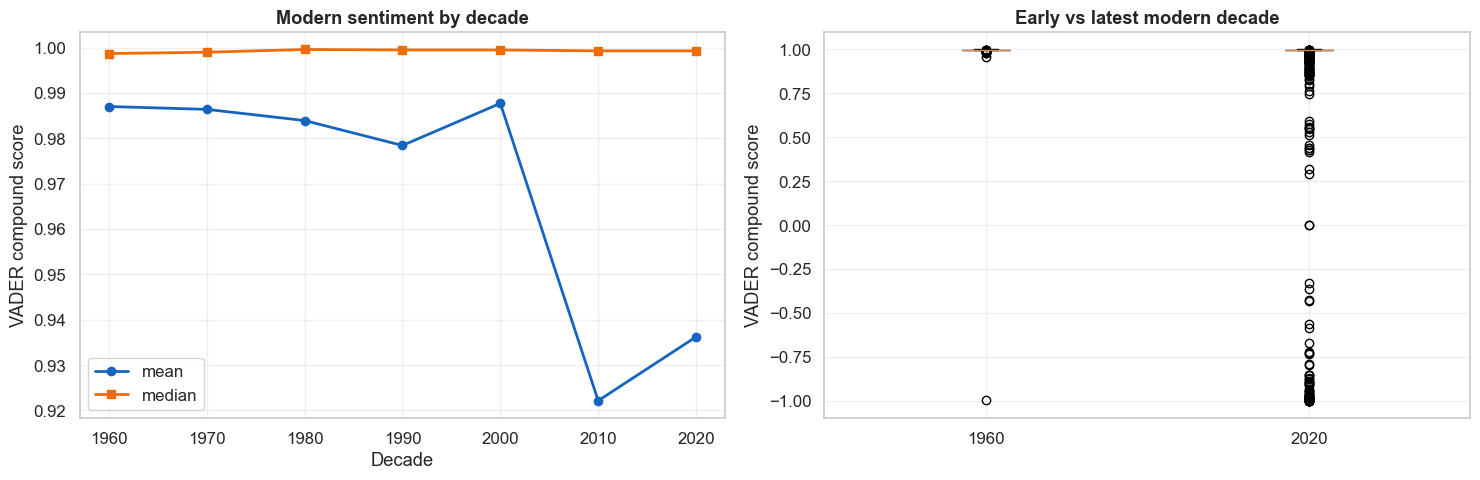

        count   mean  median    std
decade                             
1960      187  0.987   0.999  0.146
1970     1146  0.986   0.999  0.129
1980     1337  0.984   1.000  0.162
1990     2332  0.978   1.000  0.191
2000     3913  0.988   1.000  0.124
2010     4606  0.922   0.999  0.356
2020     2763  0.936   0.999  0.326
CPU times: total: 641 ms
Wall time: 667 ms


In [29]:
%%time

# RQ3.4 — Sentiment trends by modern decade
if 'vader_compound' not in LIBRARY.columns or LIBRARY['vader_compound'].isna().all():
    sentiment_df = read_processed_csv('DOC_SENTIMENT', index_col='doc_id')
    LIBRARY = LIBRARY.drop(columns=[c for c in sentiment_df.columns if c in LIBRARY.columns], errors='ignore')
    LIBRARY = LIBRARY.join(sentiment_df, how='left')
    MODERN_LIBRARY = LIBRARY[LIBRARY['year_num'].ge(MODERN_START_YEAR)].copy()

sentiment_col = 'vader_compound'
modern_sent = MODERN_LIBRARY.dropna(subset=['year_num', sentiment_col]).copy()
modern_sent['decade'] = (modern_sent['year_num'] // 10 * 10).astype(int)

decade_sent_summary = modern_sent.groupby('decade')[sentiment_col].agg(['count', 'mean', 'median', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(decade_sent_summary.index, decade_sent_summary['mean'], marker='o', linewidth=2, color='#1565c0', label='mean')
axes[0].plot(decade_sent_summary.index, decade_sent_summary['median'], marker='s', linewidth=2, color='#ef6c00', label='median')
axes[0].set_xlabel('Decade')
axes[0].set_ylabel('VADER compound score')
axes[0].set_title('Modern sentiment by decade', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

valid_decades = sorted(decade_sent_summary.index.tolist())
if len(valid_decades) >= 2:
    first_dec = valid_decades[0]
    last_dec = valid_decades[-1]
    period_box = [
        modern_sent.loc[modern_sent['decade'] == first_dec, sentiment_col],
        modern_sent.loc[modern_sent['decade'] == last_dec, sentiment_col],
    ]
    bp = axes[1].boxplot(period_box, labels=[str(first_dec), str(last_dec)], patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#90caf9', '#ffcc80']):
        patch.set_facecolor(color)
    axes[1].set_title('Early vs latest modern decade', fontweight='bold')
    axes[1].set_ylabel('VADER compound score')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Not enough decades for comparison', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

print(decade_sent_summary.round(3))

---

## Section 4 — Semantic Analysis: Word Embeddings & Similarity

Explore the semantic space of key Catholic concepts using Word2Vec embeddings and t-SNE visualization.

Running t-SNE (may take 30–60 seconds)...


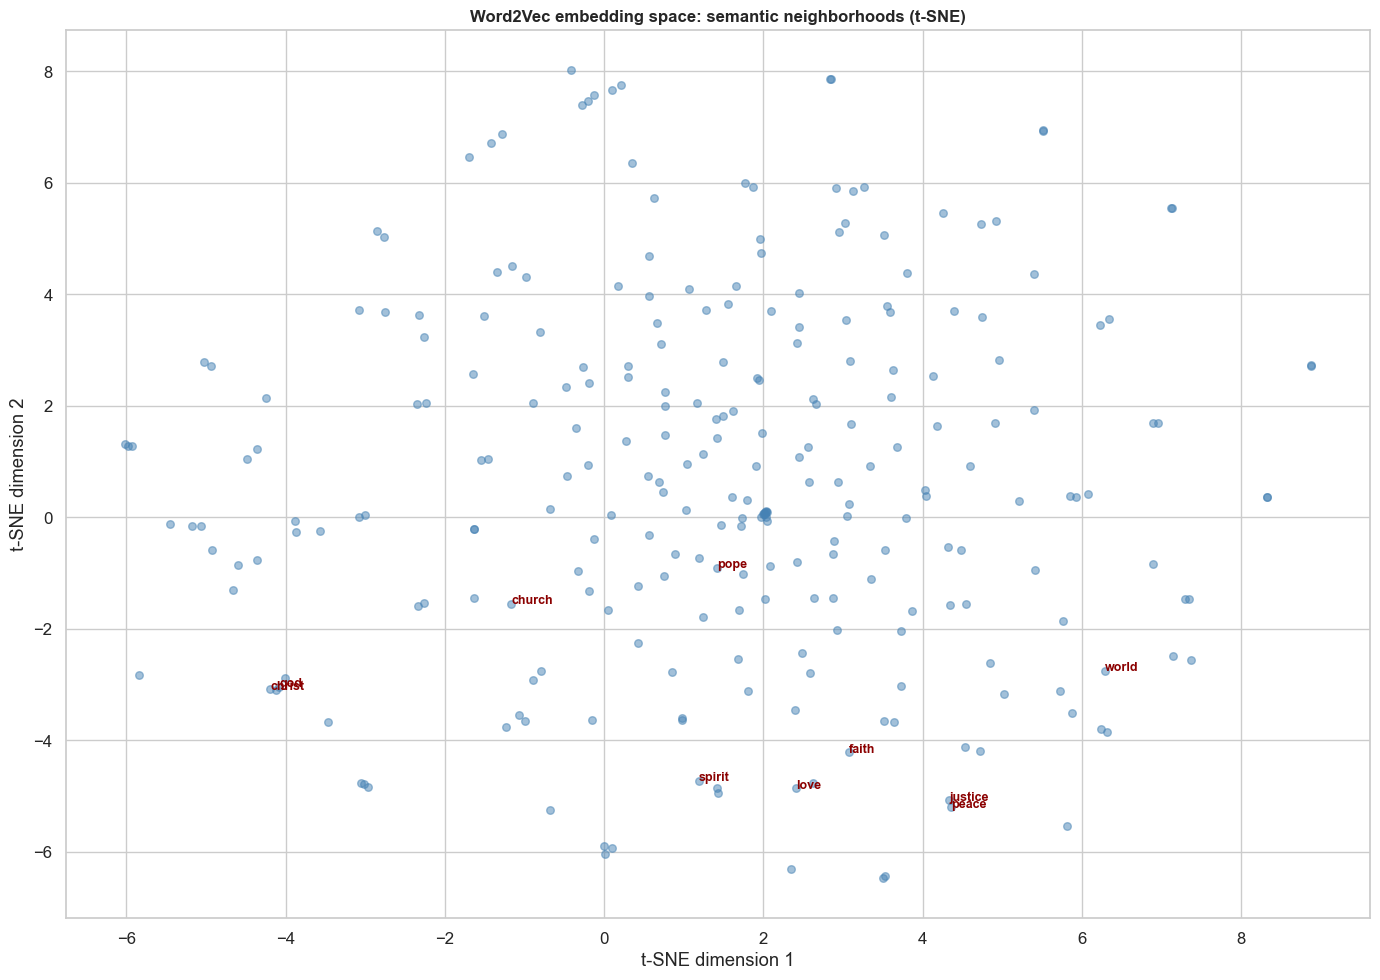

Embedded and projected 262 frequent terms.
CPU times: total: 5.59 s
Wall time: 2.17 s


In [30]:
%%time

# 4.1 — t-SNE visualization of Word2Vec embeddings (top 300 terms)
embedding_terms = [term for term in VOCAB.nlargest(300, 'n').index if term in EMBEDDINGS.index]
embedding_subset = EMBEDDINGS.loc[embedding_terms].values

print('Running t-SNE (may take 30–60 seconds)...')
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
embeddings_2d = tsne.fit_transform(embedding_subset)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=30, alpha=0.5, color='steelblue')

key_terms = ['pope', 'church', 'christ', 'faith', 'justice', 'love', 'peace', 'labor',
             'poor', 'brother', 'world', 'god', 'spirit', 'soul', 'sacred', 'moral']
for term in key_terms:
    if term in embedding_terms:
        term_idx = embedding_terms.index(term)
        ax.annotate(term, xy=embeddings_2d[term_idx], fontsize=9, fontweight='bold', color='darkred')

ax.set_title('Word2Vec embedding space: semantic neighborhoods (t-SNE)', fontweight='bold', fontsize=12)
ax.set_xlabel('t-SNE dimension 1')
ax.set_ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.show()

print(f"Embedded and projected {len(embedding_terms)} frequent terms.")

In [31]:
%%time

# 4.2 — Word2Vec neighborhoods using report-aligned semantic categories
def find_nearest_neighbors(word, embeddings_df, n=8):
    if word not in embeddings_df.index:
        return f"Word '{word}' not in vocabulary."

    word_embedding = embeddings_df.loc[word].values
    similarities = embeddings_df.apply(lambda row: 1 - cosine(word_embedding, row.values), axis=1)
    return similarities.nlargest(n + 1)[1:]

query_terms = {
    'Social Teaching': ['labor', 'justice', 'social'],
    'Church Structure': ['church', 'pontiff', 'magisterium'],
    'Modern World': ['modern', 'culture', 'global'],
}

for category, terms in query_terms.items():
    print(f"\n{'=' * 60}")
    print(category)
    print('=' * 60)
    for term in terms:
        neighbors = find_nearest_neighbors(term, EMBEDDINGS, n=8)
        if isinstance(neighbors, str):
            print(f"  {term}: {neighbors}")
        else:
            print(f"  {term}: {', '.join(neighbors.index.tolist())}")


Social Teaching
  labor: labour, toil, work, sweat, activity, zeal, worker, undertaking
  justice: equity, fairness, moderation, honesty, solidarity, legality, concord, righteousness
  social: societal, civic, structural, society, institutional, political, moral, thesocial

Church Structure
  church: faithful, community, mystical, she, mission, christian, unity, believer
  pontiff: pope, rota, emperor, curia, tribunal, empire, centurion, pontifffrancis
  magisterium: teaching, directive, doctrine, authoritatively, pronouncement, norm, hierarchy, gentiumon

Modern World
  modern: digital, secularized, contemporary, modem, globalized, changing, economics, evolution
  culture: civilization, religion, cultural, mentality, christianity, science, mindset, value
  global: worldwide, globalization, migration, environmental, sustainable, multilateral, planetary, ecological
CPU times: total: 5.19 s
Wall time: 5.22 s
